In [17]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.special import gamma, factorial
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

#SCATTERING_STRENGTH = -24.84 # MeV, Name adopted from convention in scattering problems
SCATTERING_RANGES = [0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2, 3.6, 4.0] # fm
NN_REDUCED_MASS = 939.6 / 2 #MeV
HBAR_C = 197.3 #MeV fm
R_MAX = 400
ASYMPTOTIC_FIT_LOWER_VALUE = 2250 # This changes the region the asymptotic fit is done to 
DESIRED_SCATTERING_LENGTH = -18.9 # This can be tweaked later on for whatever value we want to work on.

In [18]:
def neutron_neutron_potential(radius, scattering_stength, scattering_range): #form of the interaction potential
    return 2 * (NN_REDUCED_MASS / HBAR_C**2) * scattering_stength * np.exp(-(
        radius / scattering_range)**2)

def second_order_ode_solver(S, r_vals, b, r_max = R_MAX):
    """
    Only valid to solve problems of the form u''(r) = V'(r) u(r)
    where V'(r) = M/(hbar*c)**2 * V(r), where V(r) is our neutron-
    neutron potnetial.
    """
    derivative_inital_value = 1
    reduced_func_inital_value = 0
    inital_values = [derivative_inital_value, reduced_func_inital_value]

    if type(S) == np.ndarray:
        S = S[0]

    def func(t, y):
        return [neutron_neutron_potential(t, S, b) * y[1], y[0]]

    min_and_max_values = [0, R_MAX]
    soloution = solve_ivp(func, min_and_max_values, inital_values, t_eval=r_vals)
    return soloution

def asymptotic_fit(r_vals, u_r_vals):
    def func(r, A, a_s):
        return A * (1 - r / a_s)
    asym_fit_params, asym_fit_covarience = scipy.optimize.curve_fit(func, r_vals, u_r_vals, p0=[1, -15])
    return asym_fit_params, asym_fit_covarience

def minimisation_function(r_vals, scattering_ranges=SCATTERING_RANGES, INITAL_GUESS= -1, convergence_value=DESIRED_SCATTERING_LENGTH):

    def func_to_minimize(scattering_strength, r_vals, scattering_range, asymptotic_fit_value=ASYMPTOTIC_FIT_LOWER_VALUE):
        """
        Defined to work in the minimisation function specified. We are fitting to scatterin_strength so that
        varaible MUST come first
        """
        sol1 = second_order_ode_solver(scattering_strength, r_vals, scattering_range)
        asymptotic_fit_parameters, asymptotic_fit_covarience = asymptotic_fit(r_vals[asymptotic_fit_value:], sol1.y[1][asymptotic_fit_value:])
        return np.abs(asymptotic_fit_parameters[1] - convergence_value)

    scattering_strenths = []
    for i in scattering_ranges:
        param_min_value_dict = minimize(lambda scatt_strength:
                                        func_to_minimize(scatt_strength, r_vals, i),
                                        INITAL_GUESS,
                                        method='Nelder-Mead',
                                        options={'xatol': 1e-8, 'disp': False})
        scattering_strenths.append(param_min_value_dict['x'][0])
    
                                
    return scattering_strenths


In [20]:
r_vals = np.linspace(0, R_MAX, 30001)
scattering_strenths = minimisation_function(r_vals)
print(scattering_strenths)

[-678.7410947859297, -165.8526020646098, -72.08031597733509, -39.66830950975424, -24.843543088436178, -16.886183118820224, -12.148332095146205, -9.110808974504485, -7.055014079809201, -5.6027363002300365]


In [21]:
#sol1 = second_order_ode_solver(r_vals, SCATTERING_STRENGTH, SCATTERING_RANGE)
scattering_lengths = []
scattering_uncertainties=[]
for i in enumerate(SCATTERING_RANGES):
    sol1 = second_order_ode_solver(scattering_strenths[i[0]], r_vals, i[1])
    asymptotic_fit_parameters, asymptotic_fit_covarience = asymptotic_fit(r_vals[1000:], sol1.y[1][1000:])
    scattering_lengths.append(asymptotic_fit_parameters[1])
    scattering_uncertainties.append(np.sqrt(asymptotic_fit_covarience[1, 1]))

print(scattering_lengths)
print(scattering_uncertainties)
"""
sol1 = second_order_ode_solver(scattering_strenths[4], r_vals, 2)
asymptotic_fit_parameters, asymptotic_fit_covarience = asymptotic_fit(r_vals[1000:], sol1.y[1][1000:])
print(asymptotic_fit_parameters)
print(asymptotic_fit_covarience)
"""

[-18.89999999791309, -18.90000000021374, -18.899999990134507, -18.89999998435135, -18.89999999830809, -18.899999988187176, -18.899999993721128, -18.899999933942492, -18.899997303822094, -18.899988809759428]
[1.0590564481755266e-15, 4.903572518011208e-16, 7.963356371611052e-16, 4.695700487563608e-13, 5.167621932601273e-13, 2.2623615393250106e-12, 6.6654120464983384e-12, 5.693927806360309e-09, 1.498204636249689e-07, 4.2898627143306037e-07]


'\nsol1 = second_order_ode_solver(scattering_strenths[4], r_vals, 2)\nasymptotic_fit_parameters, asymptotic_fit_covarience = asymptotic_fit(r_vals[1000:], sol1.y[1][1000:])\nprint(asymptotic_fit_parameters)\nprint(asymptotic_fit_covarience)\n'

Text(0, 0.5, 'Scattering Strength / MeV')

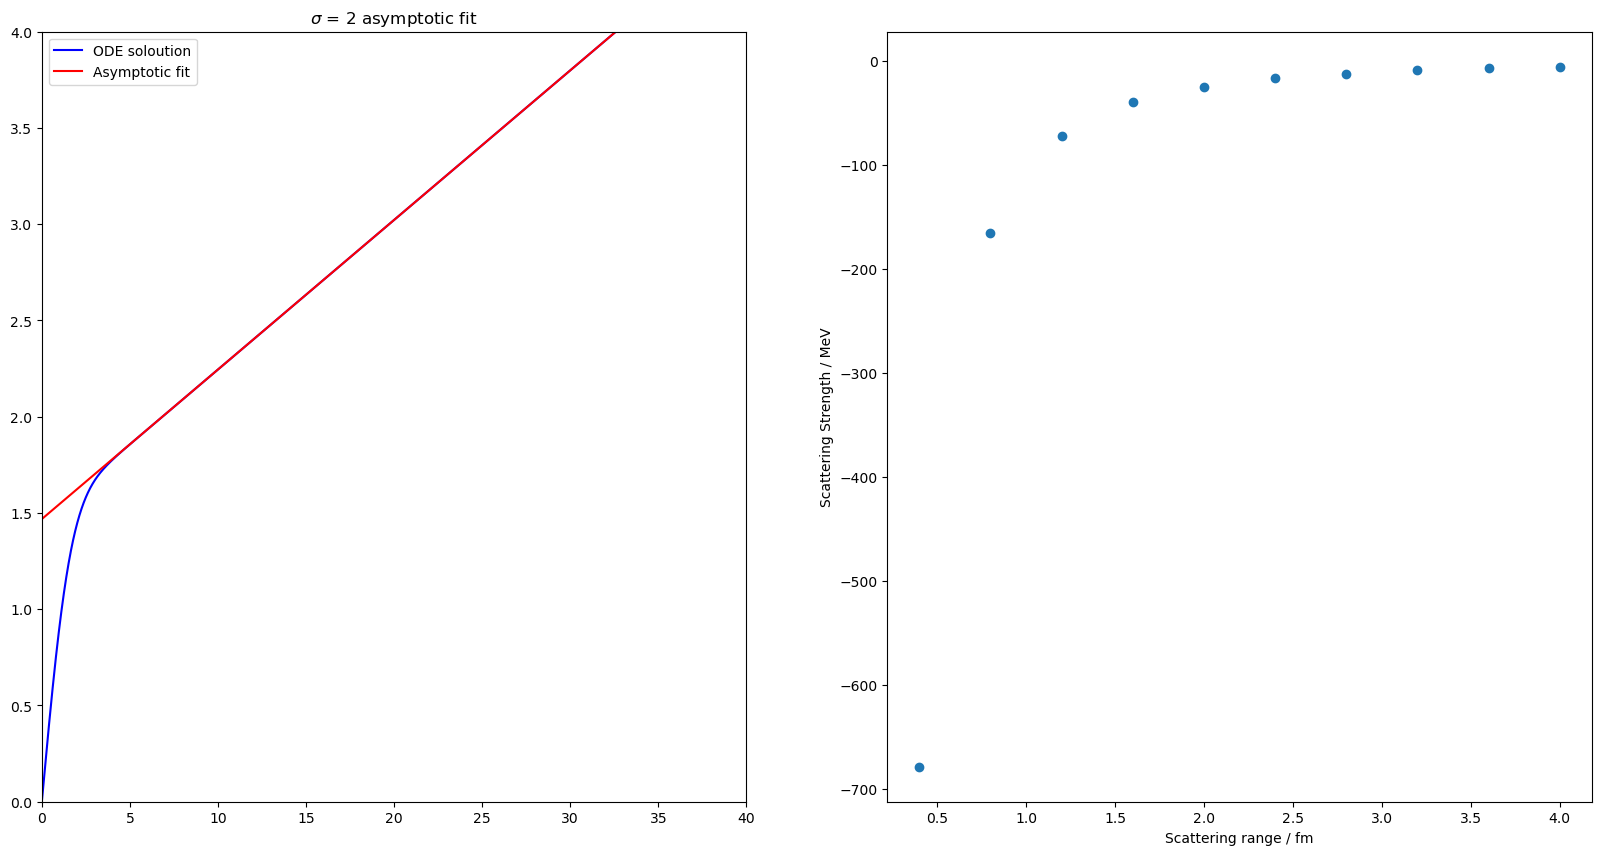

In [22]:
r_vals = np.linspace(0, R_MAX, 30001)
sol1 = second_order_ode_solver(scattering_strenths[4], r_vals, 2)
asymptotic_fit_parameters, asymptotic_fit_covarience = asymptotic_fit(r_vals[1000:], sol1.y[1][1000:])


fig = plt.figure(figsize=(20, 10))
spec = fig.add_gridspec(ncols=2, nrows=1)
ax_1 = fig.add_subplot(spec[0, 0])
ax_1.plot(r_vals, sol1.y[1], c='b', label='ODE soloution')
ax_1.plot(r_vals, asymptotic_fit_parameters[0] * (1 - (r_vals) / asymptotic_fit_parameters[1]), c='r', label='Asymptotic fit')
ax_1.set_xlim(left=0, right=40)
ax_1.set_ylim(bottom=0, top=4)
ax_1.legend()
ax_1.set_title(r'$\sigma$ = 2 asymptotic fit')

ax_2 = fig.add_subplot(spec[0, 1])
ax_2.scatter(SCATTERING_RANGES, scattering_strenths)
ax_2.set_xlabel('Scattering range / fm')
ax_2.set_ylabel('Scattering Strength / MeV')




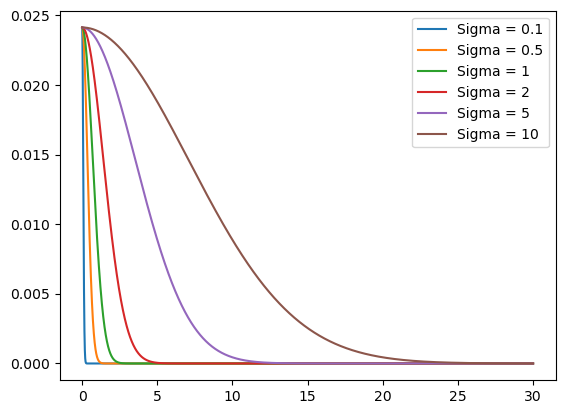

In [25]:
fig = plt.figure()
ax = fig.add_subplot()
range_params = [0.1, 0.5, 1, 2, 5, 10]
r_vals = np.linspace(0, 30, 10000)
for i in range_params:
    ax.plot(r_vals, neutron_neutron_potential(r_vals, 1, i), label=(f'Sigma = {i}'))
ax.legend()
